# Ch.2 数値計算の基礎

In [10]:
using Plots

## .1 ベクトル・行列計算

### 1.1 ベクトルの計算
juliaにおけるベクトル計算
- ベクトルに対してスカラー値をかけると要素ごとに計算される
- ベクトルのサイズが同じであれば、ベクトル同士の和も計算される
- 同じサイズのベクトル同士の掛け算は定義されておらず、要素積を計算する場合は `.`でブロードキャストする必要がある
- 内積の計算もでき、`sum(a .* b) = a' * b` は同じ結果になる

In [11]:
a = [1, 2, 3]
2 * a

3-element Vector{Int64}:
 2
 4
 6

In [12]:
b = [4, 5, 6]
a + b

3-element Vector{Int64}:
 5
 7
 9

In [13]:
a * b

MethodError: MethodError: no method matching *(::Vector{Int64}, ::Vector{Int64})
The function `*` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  *(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:596
  *(!Matched::LinearAlgebra.Adjoint{<:Any, <:SparseArrays.CHOLMOD.Sparse}, ::VecOrMat)
   @ SparseArrays C:\Users\d19008\AppData\Local\Programs\Julia-1.11.5\share\julia\stdlib\v1.11\SparseArrays\src\solvers\cholmod.jl:1419
  *(!Matched::LinearAlgebra.Adjoint{<:Number, <:AbstractVector}, ::AbstractVector{<:Number})
   @ LinearAlgebra C:\Users\d19008\AppData\Local\Programs\Julia-1.11.5\share\julia\stdlib\v1.11\LinearAlgebra\src\adjtrans.jl:478
  ...


In [14]:
a .* b

3-element Vector{Int64}:
  4
 10
 18

In [15]:
sum(a .* b) # = a' * b

32

In [16]:
a' * b

32

### 1.2 行列の計算
行列積の計算に関して
- $m \times n$ と $n \times m$ の行列積は成り立つ
- $m \times n$ と $m \times n$ の行列積は成り立たない
- $A(m \times n), \ B(m \times n)$ とした時
  - $A+B$ はOK
  - $AB$  はNG
  - $A'B$はOK
  - $A'B \ne BA'$


In [17]:
A = [1 2 3; 
     4 5 6] # 2 x 3 matrix
B = [10 20 30;
     40 50 60] # 2 x 3 matrix
A + B

2×3 Matrix{Int64}:
 11  22  33
 44  55  66

In [18]:
A * B

DimensionMismatch: DimensionMismatch: matrix A has axes (Base.OneTo(2),Base.OneTo(3)), matrix B has axes (Base.OneTo(2),Base.OneTo(3))

In [19]:
A' * B

3×3 Matrix{Int64}:
 170  220  270
 220  290  360
 270  360  450

In [20]:
B * A'

2×2 Matrix{Int64}:
 140  320
 320  770

In [21]:
A = [1 2;
    3  4]

sol = inv(A) * [-1, 1]


2-element Vector{Float64}:
  2.999999999999999
 -1.9999999999999996

## .2 統計量の計算

In [22]:
using Statistics

In [23]:
X = rand(5)
Y = rand(2, 5)

2×5 Matrix{Float64}:
 0.138261  0.00311599  0.972203  0.106926  0.310061
 0.264127  0.0507817   0.359388  0.704798  0.1987

In [24]:
println(sum(X))

1.7431987224916654


In [25]:
println(mean(X))

0.34863974449833307


各関数の`dims`オプションを使うと、行単位/列単位の計算も指定できる

In [26]:
println(sum(Y, dims = 1))

[0.40238825658435595 0.05389766416317743 1.3315918530289754 0.8117245399360792 0.5087605048736424]


In [27]:
println(sum(Y, dims = 2))

[1.5305681351402822; 1.5777946834459482;;]


In [28]:
println(mean(Y, dims = 1))

[0.20119412829217798 0.026948832081588714 0.6657959265144877 0.4058622699680396 0.2543802524368212]


## .2.2 分散/標準偏差

In [29]:
cov(Y, dims = 1)

5×5 Matrix{Float64}:
  0.00792104   0.00299973  -0.0385661   0.0376257  -0.00700827
  0.00299973   0.00113601  -0.0146051   0.014249   -0.00265406
 -0.0385661   -0.0146051    0.187771   -0.183192    0.034122
  0.0376257    0.014249    -0.183192    0.178725   -0.0332899
 -0.00700827  -0.00265406   0.034122   -0.0332899   0.00620069

In [30]:
cov(Y, dims = 2)

2×2 Matrix{Float64}:
 0.150837   0.0100154
 0.0100154  0.0599592

## .3 統計量と確率分布のパラメーター

In [31]:
using Distributions

mu = 1.5
sigma = 2.0
z = rand(Normal(mu, sigma), 10000)
first(z, 4)

4-element Vector{Float64}:
  1.6829318422912278
  1.0136993980756774
  1.7645271816233967
 -0.08851035698111276

In [32]:
mean(z)

1.4912791197720734

In [33]:
sum(z)

14912.791197720733

## .4 微分計算

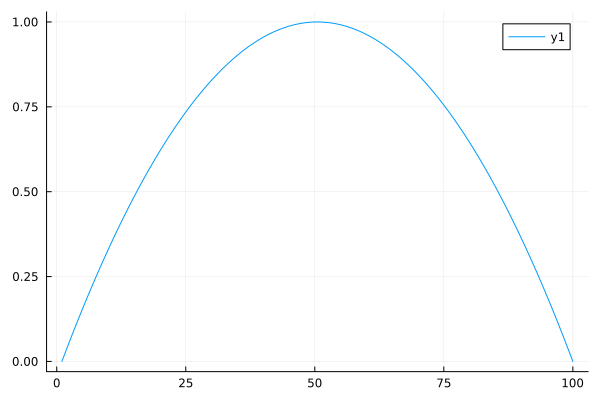

In [34]:

f(x) = -(x + 1) * (x - 1)

h = 1e-10

## 導関数f'の近似式
# f'(a) = (f(a+h) - f(a)) / h
ft(a) = (f(a + h) - f(a)) / h

xs = range(-1, 1, length = 100)


f.(xs)
ft.(xs)

plot(f.(xs))

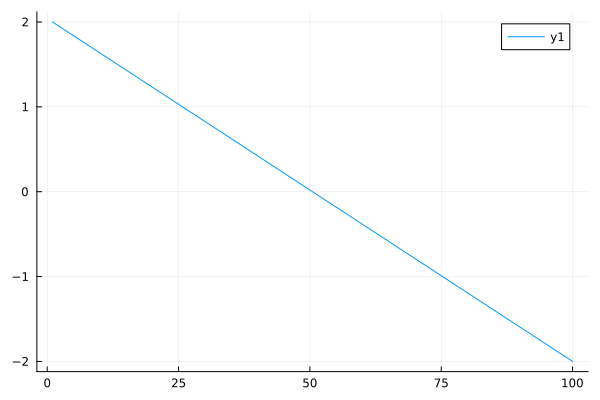

In [35]:
plot(ft.(xs))

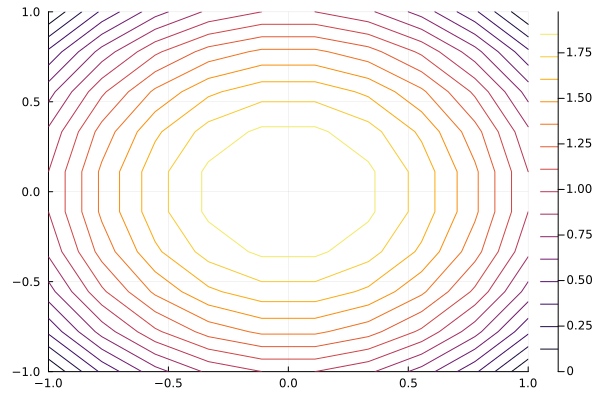

In [36]:
L = 10
xs1 = range(-1, 1, length = L)
xs2 = range(-1, 1, length = L)

f2(x) = -(x .+ 1)' * (x .- 1)
∇f2(x) = -2x

z_book = [f2([x1 x2]) for x1 in xs1, x2 in xs2]

z = zeros(L, L) # L×Lの行列を初期化する
for i in 1:L, j in 1:L
    z[i,j] = f2([xs1[i], xs2[j]])
end

contour(xs1, xs2, z')

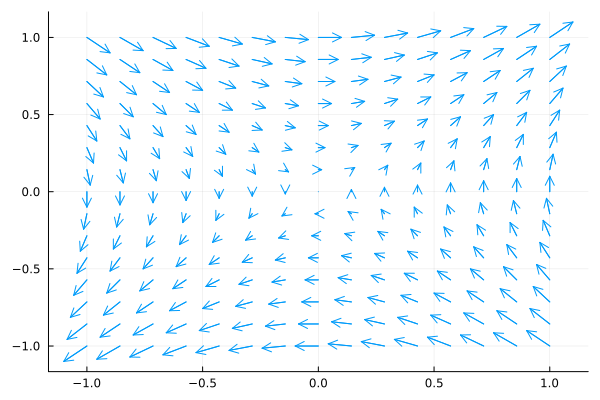

In [37]:
xe = range(-1, 1, length=15)
ye = range(-1, 1, length=15)

x = repeat(xe, outer=length(ye))
y = repeat(ye, inner=length(xe));

u = y
v = x

k = 0.1
quiver(x, y, quiver=(k*u, k*v))


In [38]:
x'

1×225 adjoint(::Vector{Float64}) with eltype Float64:
 -1.0  -0.857143  -0.714286  -0.571429  …  0.571429  0.714286  0.857143  1.0

In [39]:
repeat([1,2], outer = 3)

6-element Vector{Int64}:
 1
 2
 1
 2
 1
 2

In [40]:
repeat([1,2], inner = 3)

6-element Vector{Int64}:
 1
 1
 1
 2
 2
 2

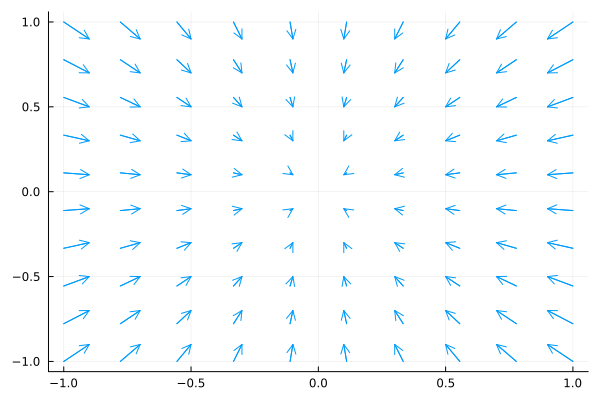

In [41]:
L = 10
xs1 = range(-1, 1, length = L)
xs2 = range(-1, 1, length = L)


vec1 = zeros(L, L) # L×Lの行列を初期化する

vec1 = [∇f2([x1, x2])[1] for x1 in xs1, x2 in xs2]
vec2 = [∇f2([x1, x2])[2] for x1 in xs1, x2 in xs2]

x = repeat(xs1, outer=L)
y = repeat(xs2, inner=L);

# quiver(x, y, quiver = (0.2 * vec(vec1), 0.2 * vec(vec2)))

quiver(x, y, quiver = (0.05 * vec(vec1), 0.05 * vec(vec2)))

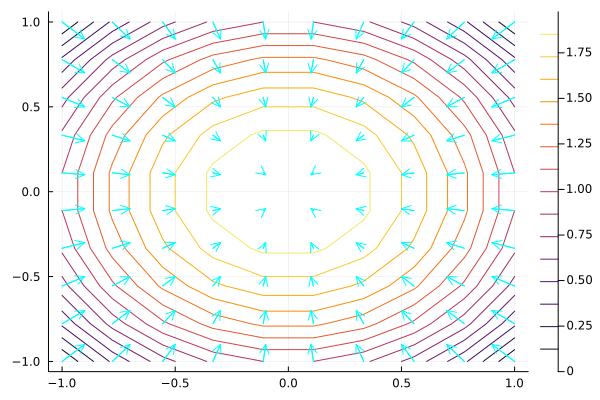

In [42]:
contour(xs1, xs2, z')
quiver!(x, y, quiver = (0.05 * vec(vec1), 0.05 * vec(vec2)), color = :cyan)

### .4.3 自動微分 `ForwardDiff`

In [43]:
using ForwardDiff

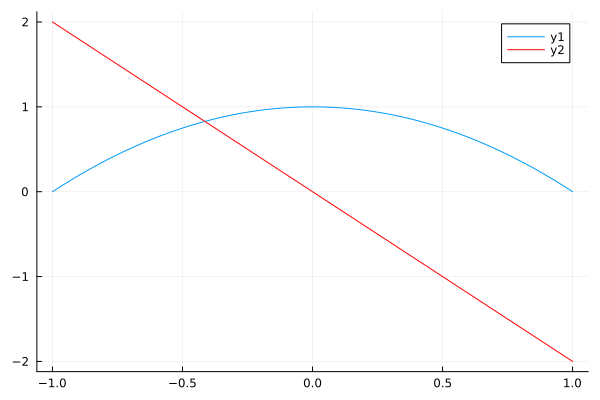

In [44]:
f(x) = -(x + 1) * (x - 1) # -x^2 - 1
df2(x) = ForwardDiff.derivative(f, x)

xs = range(-1, 1, length=100)

plot(xs, f.(xs))
plot!(xs, df2.(xs), color=:red)

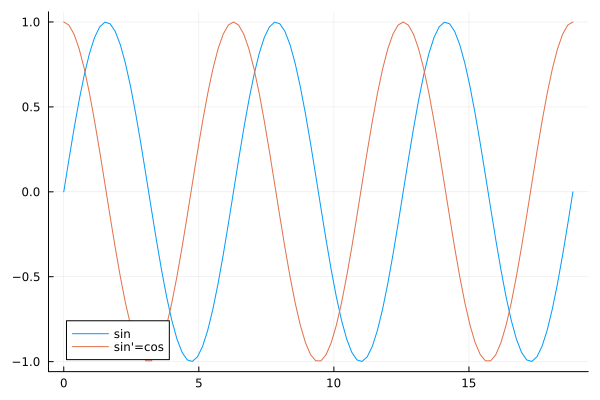

In [45]:
xs = range(0, 2pi*3, length=100)
plot(xs, sin.(xs), label = "sin")
plot!(xs, map(x -> ForwardDiff.derivative(sin, x), xs), label="sin'=cos")

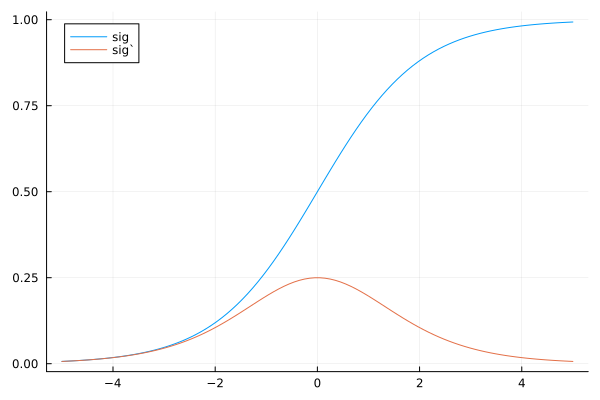

In [46]:
sig(x) = 1 / (1 + exp(-x))

xs = range(-5, 5, length = 100)

plot(xs, sig.(xs), label="sig")
plot!(xs, map(x -> ForwardDiff.derivative(sig, x), xs), label="sig`")

## .5 関数の最適化

### .5.1 1変数関数の勾配法

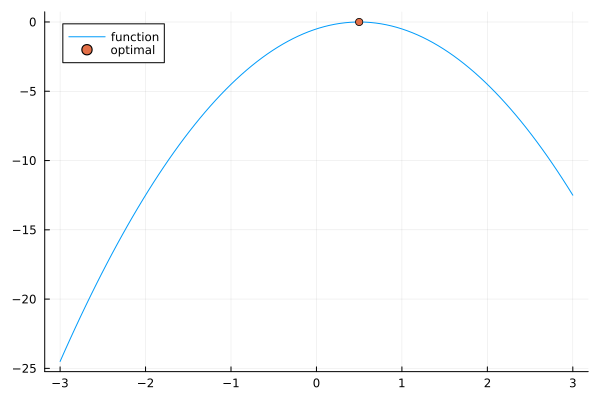

In [47]:
x_opt = 0.5
f(x) = -2(x - x_opt)^2
xs = range(-3, 3, length = 100)

plot(xs, f.(xs), label = "function")
scatter!((x_opt, f(x_opt)), label = "optimal")


勾配法は単純な最適化手法で、現在の位置から最も高くなる方向へ進むということを行う。
最も高くなるということは微分した値が最も大きいということである。
1変数の場合は単純に上るか下がるのみを考えれば良い

ステップサイズを$\eta$とすると、$2 \ge i \ge \text{maxiter}$で下記を繰り返す

$$
x_i = x_{i-1} + \eta f'(x_{i-1})
$$

In [48]:
function gradient_method_1dim(f, x_init, eta, maxiter)

    x_seq = Array{typeof(x_init), 1}(undef, maxiter)

    df(x) = ForwardDiff.derivative(f, x)

    x_seq[1] = x_init

    for i in 2:maxiter
        x_seq[i] = x_seq[i-1] + eta * df(x_seq[i-1])
    end

    x_seq
end


gradient_method_1dim (generic function with 1 method)

In [49]:
x_init = -2.5
maxiter = 20
eta = 0.1

x_seq = gradient_method_1dim(f, x_init, eta, maxiter)
f_seq = f.(x_seq)

20-element Vector{Float64}:
 -18.0
  -6.479999999999999
  -2.3327999999999993
  -0.8398079999999998
  -0.30233087999999986
  -0.10883911679999994
  -0.03918208204799999
  -0.014105549537279988
  -0.0050779978334207915
  -0.0018280792200314835
  -0.0006581085192113332
  -0.0002369190669160795
  -8.529086408978862e-5
  -3.07047110723239e-5
  -1.1053695986036396e-5
  -3.979330554973165e-6
  -1.4325589997903394e-6
  -5.157212399245448e-7
  -1.8565964637284966e-7
  -6.683747269421776e-8

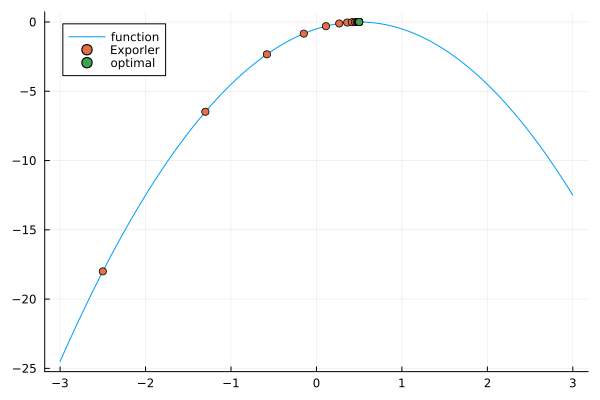

In [50]:
plot(xs, f.(xs), label = "function")
scatter!(x_seq, f.(x_seq), label = "Exporler")
scatter!((x_opt, f(x_opt)), label = "optimal")

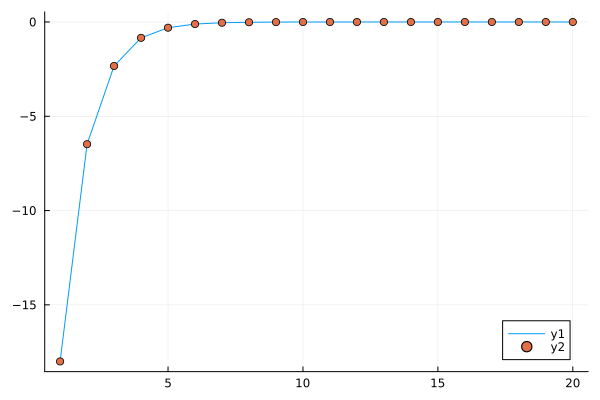

In [51]:
plot(1:maxiter, f.(x_seq))
plot!(1:maxiter, f.(x_seq), st = :scatter)

### .5.2 多変数関数の勾配法 

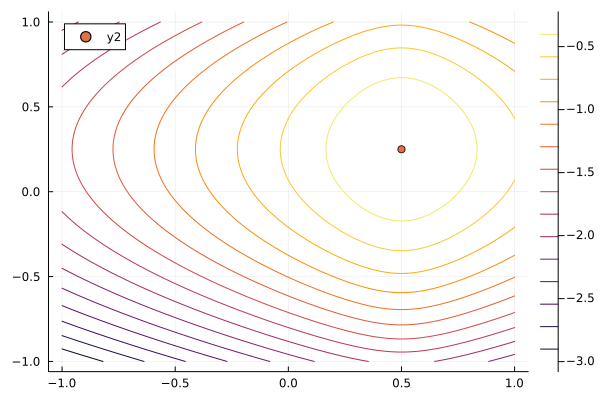

In [78]:
x_opt = [0.50, 0.25]
f2(x) = -sqrt(0.05 + (x[1] - x_opt[1])^2) - (x[2] - x_opt[2])^2

L = 100
xs1 = range(-1, 1, length = L)
xs2 = range(-1, 1, length = L)

contour(xs1, xs2, [f2([x1, x2]) for x1 in xs1, x2 in xs2]')
scatter!((x_opt[1], x_opt[2]))

In [53]:
function gradient_method(f, x_init, eta, maxiter)

    x_seq = Array{typeof(x_init[1]), 2}(undef, length(x_init), maxiter)

    pfx(x) = ForwardDiff.gradient(f, x)
    x_seq[:, 1] = x_init

    for i in 2:maxiter
        x_seq[:, i] = x_seq[:, i-1] + eta * pfx(x_seq[:,i-1])
    end

    x_seq
end

x_init = [-0.75, -0.75]
maxiter = 20
eta = 0.1

x_seq = gradient_method(f2, x_init, eta, maxiter)



2×20 Matrix{Float64}:
 -0.75  -0.651563  -0.553396  -0.455576  …  0.49031   0.494639  0.497036
 -0.75  -0.55      -0.39      -0.262        0.227482  0.231986  0.235588

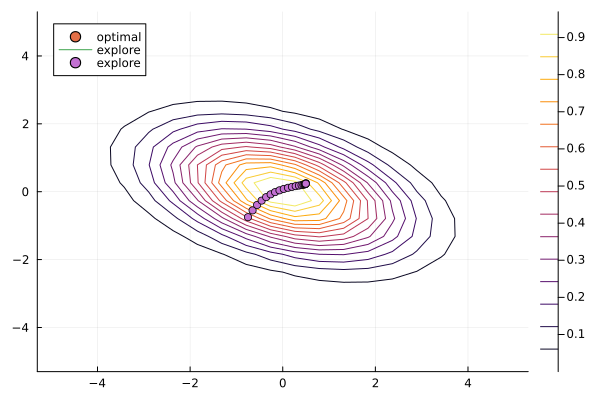

In [77]:
contour(xs1, xs2, [f2([x1, x2]) for x1 in xs1, x2 in xs2]')
scatter!((x_opt[1], x_opt[2]), label = "optimal")
plot!((x_seq[1, :], x_seq[2, :]), label = "explore")
scatter!((x_seq[1, :], x_seq[2, :]), label = "explore")

### .5.3 局所最適解と大域最適解

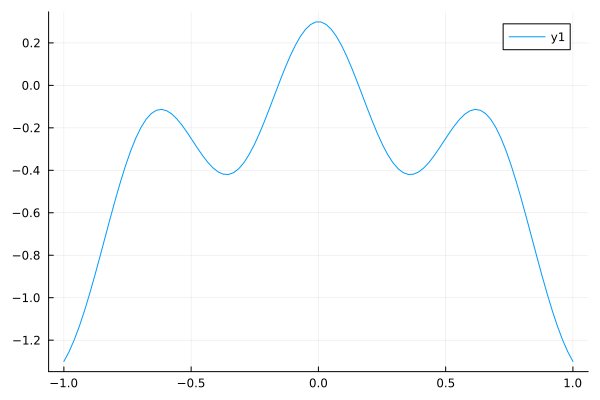

In [55]:
f_complex(x) = 0.3 * cos(3pi * x) - x^2
xs = range(-1, 1, length = 100)
plot(xs, f_complex.(xs))

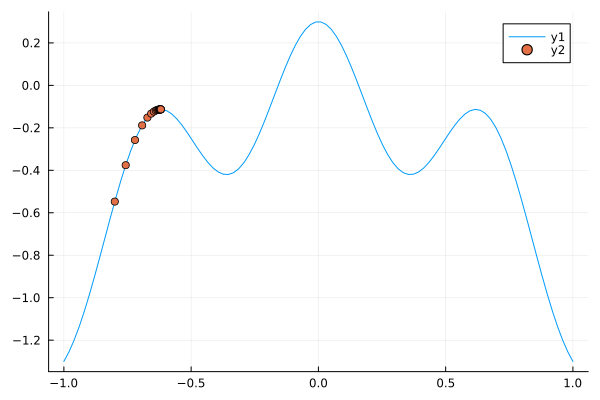

In [56]:
maxiter = 20
eta = 0.01

x_init_a = -0.8
x_seq_a = gradient_method_1dim(f_complex, x_init_a, eta, maxiter)
f_seq_a = f_complex.(x_seq_a)
plot(xs, f_complex.(xs))
scatter!(x_seq_a, f_seq_a)


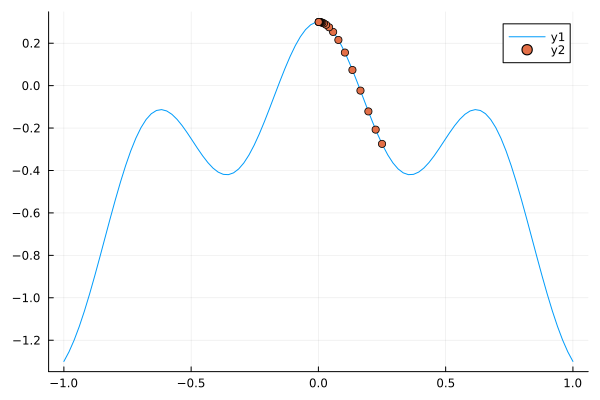

In [57]:
x_init_b = 0.25
x_seq_b = gradient_method_1dim(f_complex, x_init_b, eta, maxiter)
f_seq_b = f_complex.(x_seq_b)
plot(xs, f_complex.(xs))
scatter!(x_seq_b, f_seq_b)

## .6 最適化によるカーブフィッティング

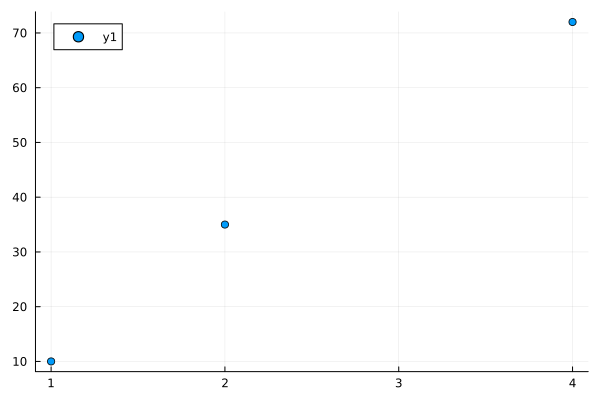

In [58]:
x_obs = [1, 2, 4]
y_obs = [10, 35, 72]

scatter(x_obs, y_obs)

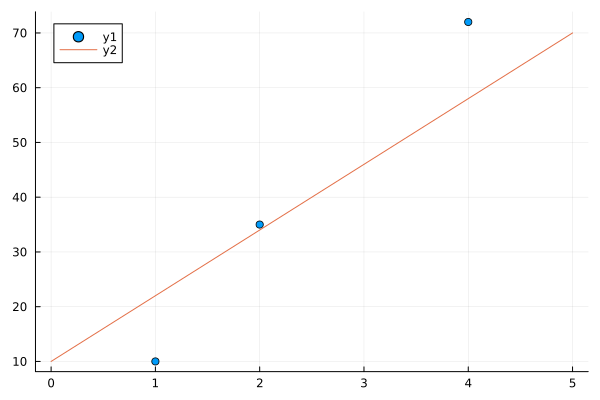

In [79]:
w = [12.0, 10.0]

f(x) = w[1] * x + w[2]

xs = range(0, 5, length = 100)

scatter(x_obs, y_obs)
plot!(xs, f.(xs))

w1 = 20.345436819385633, w2 = -8.465882327774901


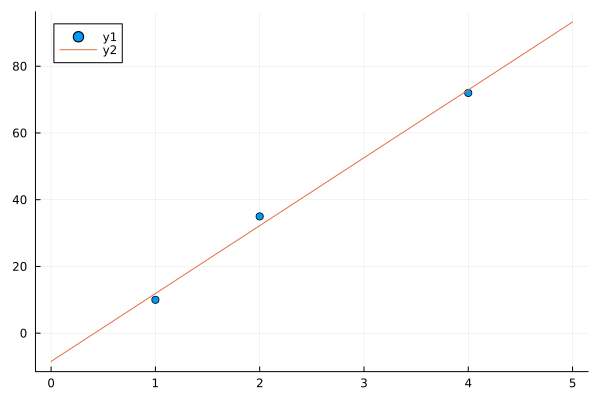

In [60]:
# 誤差関数の定義
E(w) = sum([(y_obs[n] - (w[1] * x_obs[n] + w[2]))^2 for n in 1:length(x_obs)])

# 最大化アルゴリズムのため-Eを目的関数とする
F(w) = -E(w)
w_init = [0.0, 0.0]
maxiter = 500
eta = 0.01

x
w_seq = gradient_method(F, w_init, eta, maxiter)
w1, w2 = w_seq[:, end]
println("w1 = $(w1), w2 = $(w2)")

xs = range(0, 5, length = 100)
f2(x) = w1 * x + w2
scatter(x_obs, y_obs)
plot!(xs, f2.(xs))

線形モデルの係数を解析的に解く方法
$$
\begin{align}
w_1 &= \frac{\sum^N_{n=1}(y_n-\bar{y}) x_i}{\sum^N_{n=1}(x_n-\bar{x})x_i}\\
w_2 &= \bar{y} - w_1 \bar(x)
\end{align}
$$

In [61]:

function linear_fit(y, x)
    n  = length(y)
    w1 = sum((y .- mean(y)) .* x) / sum((x .- mean(x)) .* x)
    w2 = mean(y) - w1 * mean(x)
    w1, w2
end

w1, w2 = linear_fit(y_obs, x_obs)
println("w1 = $(w1), w2 = $(w2)")


w1 = 20.35714285714286, w2 = -8.500000000000014


## .7 積分計算

### .7.1 1変数関数の数値積分

In [2]:
function approx_intergrattion(x_range, f)
    
    delta = x_range[2] - x_range[1]

    sum([f(x) * delta for x in x_range]), delta
end

rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])

rectangle (generic function with 1 method)

In [3]:

f(x) = exp(-x^2)
xs = range(-5,5, length = 100)

xs_int = range(-2, 2, length = 10)
approx1, delta  = approx_intergrattion(xs_int, f)

println("approx = $(approx1)")
println("exact = $(sqrt(pi))")

plt = plot(xs, f.(xs))
for x in xs_int
    # plot!(rectangle(x - delta / 2, x + delta / 2, f(x), f(x)), opacity=.5)
    plot!(rectangle(delta, f(x), x - delta / 2, 0), opacity=.5)
end
plot(plt)


approx = 1.7699705304277666
exact = 1.7724538509055159


UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

approx = 0.233343789106035
exact = 1.7724538509055159


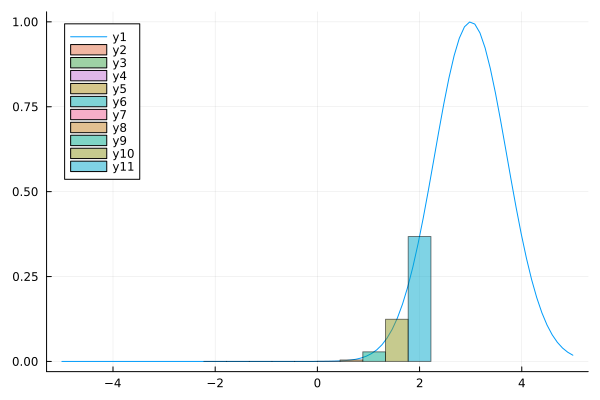

In [64]:
f(x) = exp(-(x-3)^2)
xs = range(-5,5, length = 100)

xs_int = range(-2, 2, length = 10)
approx1, delta  = approx_intergrattion(xs_int, f)

println("approx = $(approx1)")
println("exact = $(sqrt(pi))")

plt = plot(xs, f.(xs))
for x in xs_int
    # plot!(rectangle(x - delta / 2, x + delta / 2, f(x), f(x)), opacity=.5)
    plot!(rectangle(delta, f(x), x - delta / 2, 0), opacity=.5)
end
plot(plt)

approx = 0.2586448037358885
exact = 1.7724538509055159


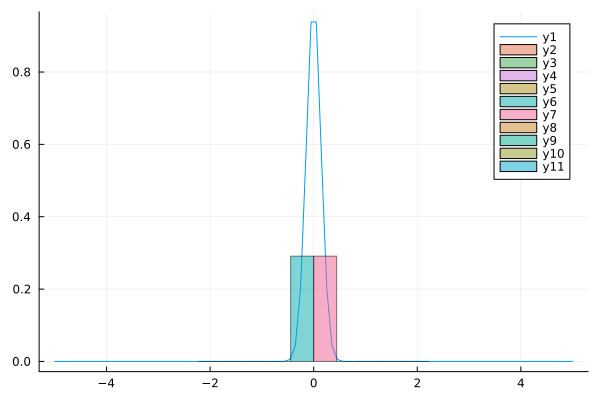

In [65]:
f(x) = exp(-(x/0.2)^2)
xs = range(-5,5, length = 100)

xs_int = range(-2, 2, length = 10)
approx1, delta  = approx_intergrattion(xs_int, f)

println("approx = $(approx1)")
println("exact = $(sqrt(pi))")

plt = plot(xs, f.(xs))
for x in xs_int
    # plot!(rectangle(x - delta / 2, x + delta / 2, f(x), f(x)), opacity=.5)
    plot!(rectangle(delta, f(x), x - delta / 2, 0), opacity=.5)
end
plot(plt)

### .7.2 多変数関数の数値積分

In [ ]:
using LinearAlgebra

A = [0.5 0.3;
     0.3 1.0]
det(A)

0.41000000000000003

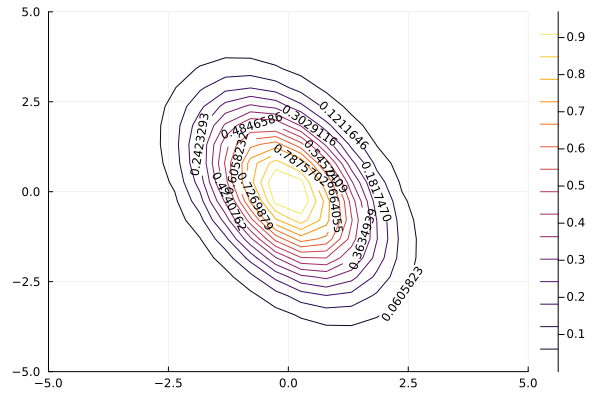

In [ ]:
D = 2
A = [0.5 0.3;
     0.3 1.0]
f2(x) = exp(-0.5 * x' * A * x)

L = 20
xs1 = range(-5, 5, length = L)
xs2 = range(-5, 5, length = L)

contour(
    xs1, xs2,
    [f2([x1, x2]) for x1 in xs1, x2 in xs2],
    # contour_labels=true
    clabels = true
    )

In [ ]:
function approx_intergration_2dim(x_range, f)
    
    delta = x_range[2] - x_range[1]

    sum([f([x1, x2]) * delta^2 for x1 in x_range, x2 in x_range]), delta
end

using LinearAlgebra


approx = 9.805714174433017
exact = 9.812686860654528


In [105]:
L = 20
x_range = range(-5, 5, length = L)
approx2, delta = approx_intergration_2dim(x_range, f2)

println("approx = $(approx2)")
println("exact  = $(sqrt((2*pi)^D / det(A)))")

approx = 9.805714174433017
exact  = 9.812686860654528


In [106]:
L = 1000
x_range = range(-100, 100, length = L)
approx2, delta = approx_intergration_2dim(x_range, f2)

println("approx = $(approx2)")
println("exact  = $(sqrt((2*pi)^D / det(A)))")

approx = 9.812686860654521
exact  = 9.812686860654528
